In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 290 (delta 54), reused 58 (delta 30), pack-reused 204 (from 1)
Receiving objects: 100% (290/290), 2.01 MiB | 14.31 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/miniml


In [2]:
from miniml.tree_based.decisiontreeregressor import DecisionTreeRegression

СВОДКА ТЕСТИРОВАНИЯ: BFS DECISION TREE REGRESSION (UPDATED)
MSE на тренировочной выборке (Miniml):  0.002695
MSE na тренировочной выборке (Sklearn): 0.002695
Идентичность аппроксимированных ступеней: 97.20%


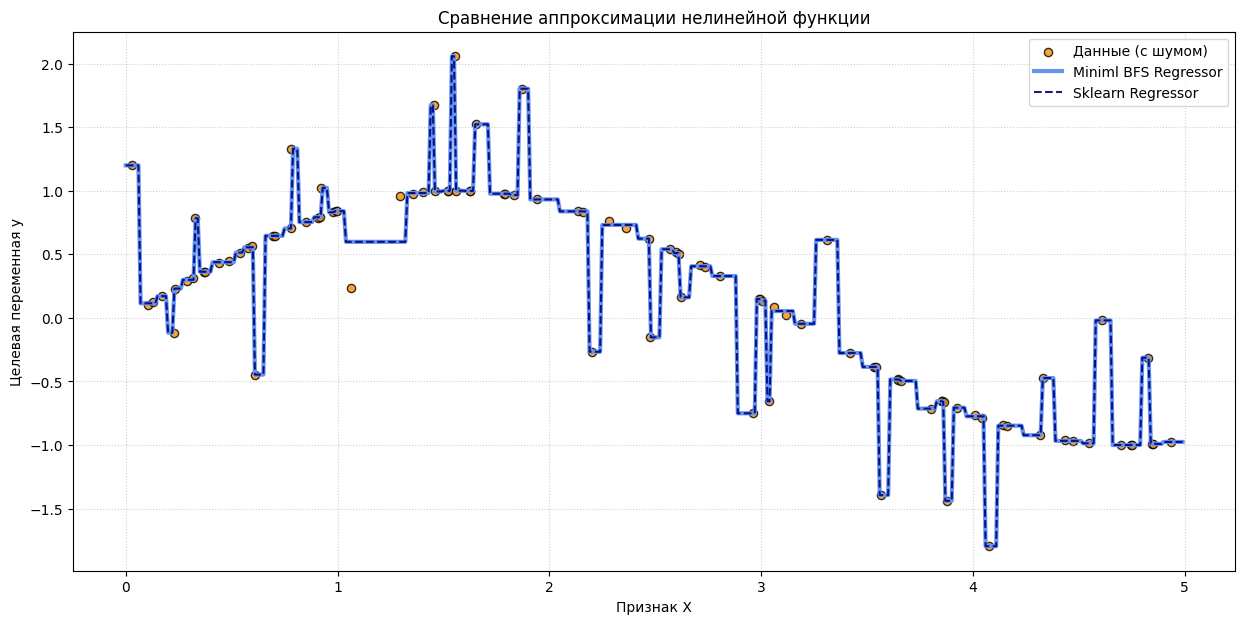

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# =====================================================================
# ТЕСТОВЫЙ ДАТАСЕТ: Нелинейная синусоида + искусственные выбросы
# =====================================================================
np.random.seed(42)
X_train = np.sort(5 * np.random.rand(100, 1), axis=0)
y_train = np.sin(X_train).ravel()

# Добавляем жесткий шум/выбросы для проверки робастности сплитов
y_train[::4] += 2.5 * (0.5 - np.random.rand(25))

# Плотная сетка точек для финальной визуализации предсказаний
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

np.random.seed(42)
X_train = np.sort(5 * np.random.rand(100, 1), axis=0)
y_train = np.sin(X_train).ravel()
y_train[::4] += 2.5 * (0.5 - np.random.rand(25))

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

MAX_DEPTH = 100
MIN_SAMPLES = 3
TOLERANCE = 1e-8
CRITERION = 'mse'

custom_reg = DecisionTreeRegression().fit(X_train, y_train, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, tol=TOLERANCE, impurity_func=CRITERION)
sk_reg = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, min_impurity_decrease=TOLERANCE, criterion='squared_error', random_state=42).fit(X_train, y_train)

y_pred_custom = custom_reg.predict(X_test)
y_pred_sklearn = sk_reg.predict(X_test)

mse_custom = mean_squared_error(y_train, custom_reg.predict(X_train))
mse_sklearn = mean_squared_error(y_train, sk_reg.predict(X_train))
preds_identity = np.mean(np.abs(y_pred_custom - y_pred_sklearn) < 1e-7) * 100

print("=" * 75)
print("СВОДКА ТЕСТИРОВАНИЯ: BFS DECISION TREE REGRESSION (UPDATED)")
print("=" * 75)
print(f"MSE на тренировочной выборке (Miniml):  {mse_custom:.6f}")
print(f"MSE na тренировочной выборке (Sklearn): {mse_sklearn:.6f}")
print(f"Идентичность аппроксимированных ступеней: {preds_identity:.2f}%")
print("=" * 75)

plt.figure(figsize=(15, 7))
plt.scatter(X_train, y_train, s=35, edgecolor="black", c="darkorange", label="Данные (с шумом)", alpha=0.8)
plt.plot(X_test, y_pred_custom, color="cornflowerblue", label=f"Miniml BFS Regressor", linewidth=3)
# ФИКС: Переменная y_pred_sklearn вместо сломанного y_pred_slate
plt.plot(X_test, y_pred_sklearn, color="navy", label="Sklearn Regressor", linewidth=1.5, linestyle="--", alpha=0.9)
plt.xlabel("Признак X")
plt.ylabel("Целевая переменная y")
plt.title("Сравнение аппроксимации нелинейной функции")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()